In [79]:
import sys
sys.path.insert(0, '..')  # 親ディレクトリの Cyclist_env_RDA_2nano.py を参照

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.linalg import dft
from Cyclist_env_RDA_2nano import cyclist_env

In [80]:
# learn_data_generator.ipynb から変更せずコピー
def Radar_setting():
    T_symbol = 5.575 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545 * 1e-9

    N_ant = 16
    BW = 400 * 1e+6
    BW_sub = BW / N_ant
    N_sample = int(np.floor(T_symbol / Tc))
    rx_sample = 813 + N_sample

    mu = BW_sub / T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed / f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env


def stevec(N_ant, angle):
    # learn_data_generator.ipynb から変更せずコピー（angle はラジアン）
    resp = (np.arange(N_ant) - N_ant * 0.5 + 0.5).reshape([-1, 1])
    resp = np.exp(1j * resp * np.pi * np.sin(angle))
    return np.matrix(resp)


def physical_to_rd_indices(range_m, velocity_mps, N_trans, sym_duration, lam, Tc,
                            range_offset=620, num_range_bins=190):
    # learn_data_generator.ipynb から変更せずコピー
    c = 299792458.0
    vel_res = lam / (2.0 * sym_duration * N_trans)
    range_res = c * Tc / 2.0

    d_idx = int(np.round(velocity_mps / vel_res)) % N_trans
    r_idx = int(np.round(range_m / range_res - range_offset))

    valid = (0 <= d_idx < N_trans) and (0 <= r_idx < num_range_bins)
    return d_idx, r_idx, valid


def FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, sym_duration, lam, Tc, env):
    # learn_data_generator.ipynb から変更せずコピー
    Dopp_dft = dft(N_trans) / np.sqrt(N_trans)
    Y_dft = np.zeros((N_trans, N_ant, rx_sample), dtype=np.complex128)
    for i in range(N_ant):
        Y_dft[:, i, :] = Dopp_dft @ Y[:, i, :]

    rd_maps = []
    P_range = np.arange(190) + 620

    tx_arr = np.array(tx)
    n_fft = 2 ** (int(rx_sample + N_sample).bit_length())

    TX_F_all = fft(tx_arr, n=n_fft, axis=1)
    Y_F_all = fft(Y_dft, n=n_fft, axis=2)

    for i in range(len(est_ang)):
        current_angle = est_ang[i]
        ang_rad = current_angle * np.pi / 180

        s_vec = np.array(stevec(N_ant, ang_rad))

        w_vec = np.conjugate(s_vec).reshape(1, N_ant, 1)
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)
        w_vec = s_vec.reshape(1, N_ant, 1)
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)

        s_vec_conj_reshape = np.conjugate(s_vec).reshape(N_ant, 1)
        TX_F_combined = np.sum(TX_F_all * s_vec_conj_reshape, axis=0)

        CORR_f = Y_F_combined * np.conjugate(TX_F_combined)
        corr_time = ifft(CORR_f, axis=1)
        rdresp_single = corr_time[:, P_range]

        rd_maps.append(rdresp_single.copy())
        rd_maps.append(i)

    return rd_maps

In [81]:
T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env = Radar_setting()
N_FIXED = 10
N_trans = 89  # チャープ数

tx = env.tx()

# ターゲット座標（シミュレーション設定値）
# phys_quantities() は (n, 3) の 2D 配列を期待するため reshape している
p_bs  = np.array([250, -18, 50])
p_cy  = np.array([[-40, -6, 1]])    # cyclist (1, 3)
p_ve  = np.array([[-39.2087, -7.90536, 1]])   # vehicle (1, 3)

# 速度ベクトル（learn_data_generator と同じ設定）
v_cy = np.array([[6, 0, 0]])    # (1, 3)
v_ve = np.array([[10, 0, 0]])   # (1, 3)

# 角度グリッド
FIXED_ANGLES = np.linspace(-5, 5, N_FIXED)  # 単位: 度
print('FIXED_ANGLES:', FIXED_ANGLES)

# 物理量を計算（ステアリングベクトル・相対速度・レンジ）
phys = env.phys_quantities(
    p_bs,
    p_cy, v_cy, 1,   # cyclist: 1体
    p_ve, v_ve, 1,   # vehicle: 1体
    np.zeros((0, 3)), np.zeros((0, 3)), 0   # ランポスト: なし
)

cy_range = float(phys['range']['cyclists'][0])
cy_vel   = float(phys['relative_velocity']['cyclists'][0])
cy_ang   = float(np.degrees(phys['angle']['cyclists'][0]))
ve_range = float(phys['range']['vehicles'][0])
ve_vel   = float(phys['relative_velocity']['vehicles'][0])
ve_ang   = float(np.degrees(phys['angle']['vehicles'][0]))

print(f'cyclist : range={cy_range:.1f} m, vel={cy_vel:.2f} m/s, angle={cy_ang:.2f} deg')
print(f'vehicle : range={ve_range:.1f} m, vel={ve_vel:.2f} m/s, angle={ve_ang:.2f} deg')

FIXED_ANGLES: [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
  1.66666667  2.77777778  3.88888889  5.        ]
cyclist : range=294.4 m, vel=5.91 m/s, angle=-1.18 deg
vehicle : range=293.5 m, vel=9.85 m/s, angle=-1.55 deg


In [91]:
# both.csv を読み込んで rx_multiple() に渡す
CSV_PATH = './onlyvehicle.csv'
df_csv = pd.read_csv(CSV_PATH)

tstemp = np.round((df_csv['Time (s)'] / Tc)).values[7:]
P_rx   = df_csv['| Total Complex Impulse Response total | (W)'].values[7:]
phase  = df_csv['Phase( Total Complex Impulse Response total ) (rad)'].values[7:]

print(f'読み込みサンプル数: {len(tstemp)}')
print(f'遅延範囲: {tstemp.min():.0f} 〜 {tstemp.max():.0f} サンプル')

P_N_dB = -87.98

# rx_multiple() は env.n_cy を参照するため、vehicle のみで phys_quantities() を呼び直す
env.phys_quantities(
    p_bs,
    np.zeros((0, 3)), np.zeros((0, 3)), 0,   # cyclist: なし
    p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)

Y = env.rx_multiple(
    tx,
    [], [], [],                      # cyclist: なし
    [P_rx], [tstemp], [phase],       # vehicle
    [], [], [],
    P_N_dB, T_symbol, N_trans
)

# 両ターゲットの状態に戻す
env.phys_quantities(
    p_bs,
    p_cy, v_cy, 1,
    p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)

print(f'Y.shape: {Y.shape}')

読み込みサンプル数: 110
遅延範囲: 271 〜 944 サンプル
Y.shape: (89, 16, 3003)


In [92]:
# FFT() で RD マップを生成（learn_data_generator と同じ呼び方）
rd_maps_list = FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, FIXED_ANGLES, T_symbol, lam, Tc, env)

# (N_FIXED, N_trans, 190) complex64
rd_maps = np.array(rd_maps_list[::2], dtype=np.complex64)
print(f'rd_maps.shape: {rd_maps.shape}')

# 真値の RD ビン位置を確認
cy_d, cy_r, cy_valid = physical_to_rd_indices(cy_range, cy_vel, N_trans, T_symbol, lam, Tc)
ve_d, ve_r, ve_valid = physical_to_rd_indices(ve_range, ve_vel, N_trans, T_symbol, lam, Tc)
print(f'cyclist  : d_idx={cy_d}, r_idx={cy_r}, valid={cy_valid}')
print(f'vehicle  : d_idx={ve_d}, r_idx={ve_r}, valid={ve_valid}')

rd_maps.shape: (10, 89, 190)
cyclist  : d_idx=1, r_idx=152, valid=True
vehicle  : d_idx=1, r_idx=149, valid=True


vehicle 真値角度: -1.55°
最近傍チャネル: FIXED_ANGLES[3] = -1.67°


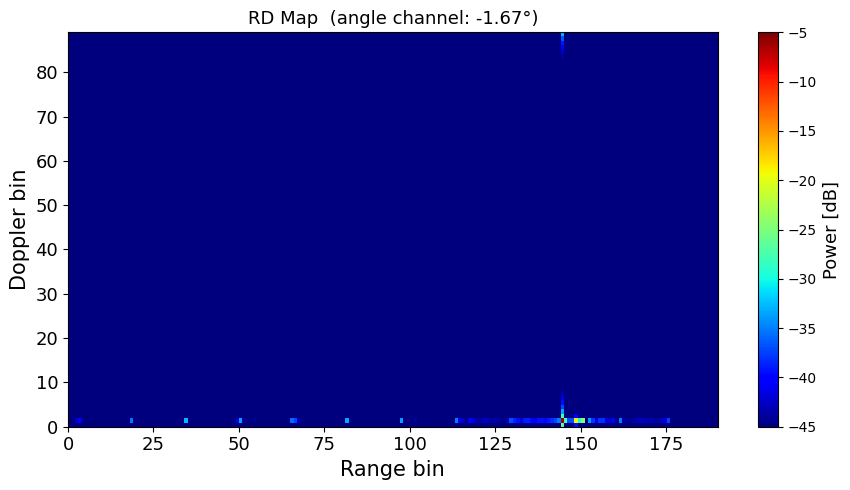

In [93]:

# --- 可視化: 車の真値角度に最も近い角度チャネルの RD マップ ---
VMAX_DB = -5.0  # 全シナリオ共通基準（vehicle ピーク -6.1 dB から決定）

best_ch = int(np.argmin(np.abs(FIXED_ANGLES - ve_ang)))
print(f'vehicle 真値角度: {ve_ang:.2f}°')
print(f'最近傍チャネル: FIXED_ANGLES[{best_ch}] = {FIXED_ANGLES[best_ch]:.2f}°')

power = np.abs(rd_maps[best_ch]) ** 2
rd_db = 10 * np.log10(power + 1e-30)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(
    rd_db,
    aspect='auto', origin='lower',
    cmap='jet', vmin=VMAX_DB - 40, vmax=VMAX_DB,
    extent=[0, rd_db.shape[1], 0, rd_db.shape[0]]
)
ax.set_xlabel('Range bin', fontsize=15)
ax.set_ylabel('Doppler bin', fontsize=15)
ax.set_title(f'RD Map  (angle channel: {FIXED_ANGLES[best_ch]:.2f}°)', fontsize=13)
ax.tick_params(labelsize=13)

cb = plt.colorbar(im, ax=ax)
cb.set_label('Power [dB]', fontsize=13)
plt.tight_layout()
plt.savefig('./rd_map_best_angle.png', dpi=150, bbox_inches='tight')
plt.show()


In [85]:

# --- vehicle のみで RD マップを生成 ---
CSV_VE = './onlyvehicle.csv'

def load_cir_csv(path, Tc, skip=3):
    """複素インパルス応答 CSV を読み込んで (tstemp, P_rx, phase) を返す。"""
    df = pd.read_csv(path)
    tstemp = np.round((df['Time (s)'] / Tc)).values[skip:]
    P_rx   = df['| Total Complex Impulse Response total | (W)'].values[skip:]
    phase  = df['Phase( Total Complex Impulse Response total ) (rad)'].values[skip:]
    return tstemp, P_rx, phase

tstemp_ve, P_rx_ve, phase_ve = load_cir_csv(CSV_VE, Tc)
print(f'vehicle CSV  サンプル数: {len(tstemp_ve)}')

env.phys_quantities(
    p_bs,
    np.zeros((0, 3)), np.zeros((0, 3)), 0,
    p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)

Y_ve = env.rx_multiple(
    tx,
    [], [], [],
    [P_rx_ve], [tstemp_ve], [phase_ve],
    [], [], [],
    P_N_dB, T_symbol, N_trans
)

env.phys_quantities(
    p_bs,
    p_cy, v_cy, 1,
    p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)

rd_maps_list_ve = FFT(N_trans, N_ant, rx_sample, Y_ve, tx, N_sample, FIXED_ANGLES, T_symbol, lam, Tc, env)
rd_maps_ve = np.array(rd_maps_list_ve[::2], dtype=np.complex64)  # (N_FIXED, 89, 190)
print(f'rd_maps_ve.shape: {rd_maps_ve.shape}')


vehicle CSV  サンプル数: 114
rd_maps_ve.shape: (10, 89, 190)


best channel  : [3] -1.67°  peak power = -29.8 dB
other channel : [9] 5.00°  peak power = -44.5 dB


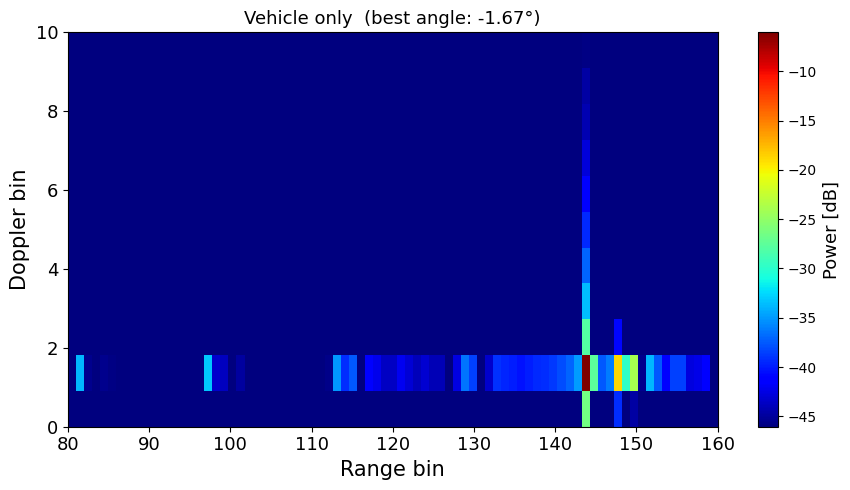

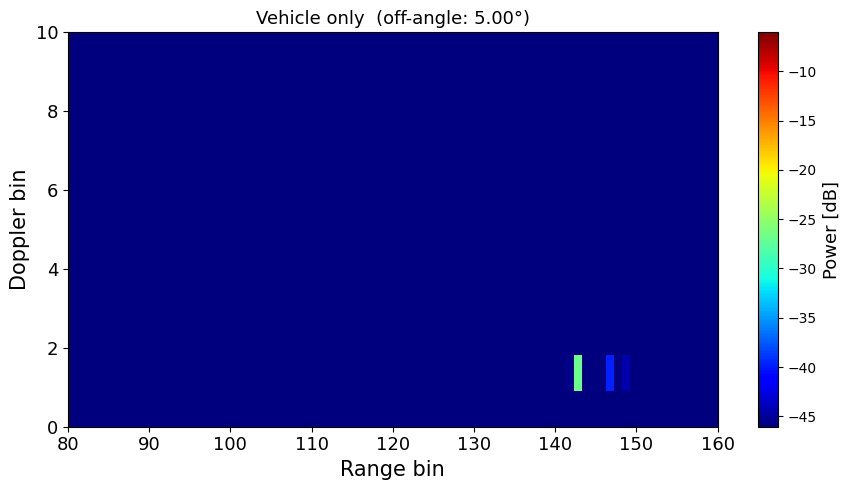

In [86]:

# --- 可視化: vehicle-only 固定範囲表示 & 最大強度差チャネル比較 ---
# 表示範囲（ビン）
R_MIN, R_MAX = 80, 160
D_MIN, D_MAX = 0,  10
DB_RANGE = 40  # 表示ダイナミックレンジ [dB]

best_ch_ve = int(np.argmin(np.abs(FIXED_ANGLES - ve_ang)))

# 全チャネルの vehicle ピーク電力を取得し、最も弱いチャネルを選ぶ
peak_powers = np.array([
    np.abs(rd_maps_ve[ch][ve_d, ve_r]) ** 2
    for ch in range(N_FIXED)
])
# best を除いて最小ピーク電力のチャネルを選ぶ（強度差が最大）
peak_powers_masked = peak_powers.copy()
peak_powers_masked[best_ch_ve] = np.inf
other_ch_ve = int(np.argmin(peak_powers_masked))

print(f'best channel  : [{best_ch_ve}] {FIXED_ANGLES[best_ch_ve]:.2f}°  peak power = {10*np.log10(peak_powers[best_ch_ve]+1e-30):.1f} dB')
print(f'other channel : [{other_ch_ve}] {FIXED_ANGLES[other_ch_ve]:.2f}°  peak power = {10*np.log10(peak_powers[other_ch_ve]+1e-30):.1f} dB')

# 両チャネルの絶対 dB（共通スケールで比較するため best チャネルの vmax を基準にする）
rd_best_abs  = 10 * np.log10(np.abs(rd_maps_ve[best_ch_ve]) ** 2 + 1e-30)
rd_other_abs = 10 * np.log10(np.abs(rd_maps_ve[other_ch_ve]) ** 2 + 1e-30)

# best チャネルのピークを基準に vmax を揃える
vmax_common = rd_best_abs.max()
vmin_common = vmax_common - DB_RANGE

crop_best  = rd_best_abs [D_MIN:D_MAX+1, R_MIN:R_MAX+1]
crop_other = rd_other_abs[D_MIN:D_MAX+1, R_MIN:R_MAX+1]

def save_rd_fig(data, title, path, vmin, vmax):
    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(
        data,
        aspect='auto', origin='lower',
        cmap='jet', vmin=vmin, vmax=vmax,
        extent=[R_MIN, R_MAX, D_MIN, D_MAX]
    )
    ax.set_xlabel('Range bin', fontsize=15)
    ax.set_ylabel('Doppler bin', fontsize=15)
    ax.set_title(title, fontsize=13)
    ax.tick_params(labelsize=13)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('Power [dB]', fontsize=13)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

save_rd_fig(
    crop_best,
    f'Vehicle only  (best angle: {FIXED_ANGLES[best_ch_ve]:.2f}°)',
    './rd_map_ve_best.png',
    vmin_common, vmax_common
)
save_rd_fig(
    crop_other,
    f'Vehicle only  (off-angle: {FIXED_ANGLES[other_ch_ve]:.2f}°)',
    './rd_map_ve_offangle.png',
    vmin_common, vmax_common
)


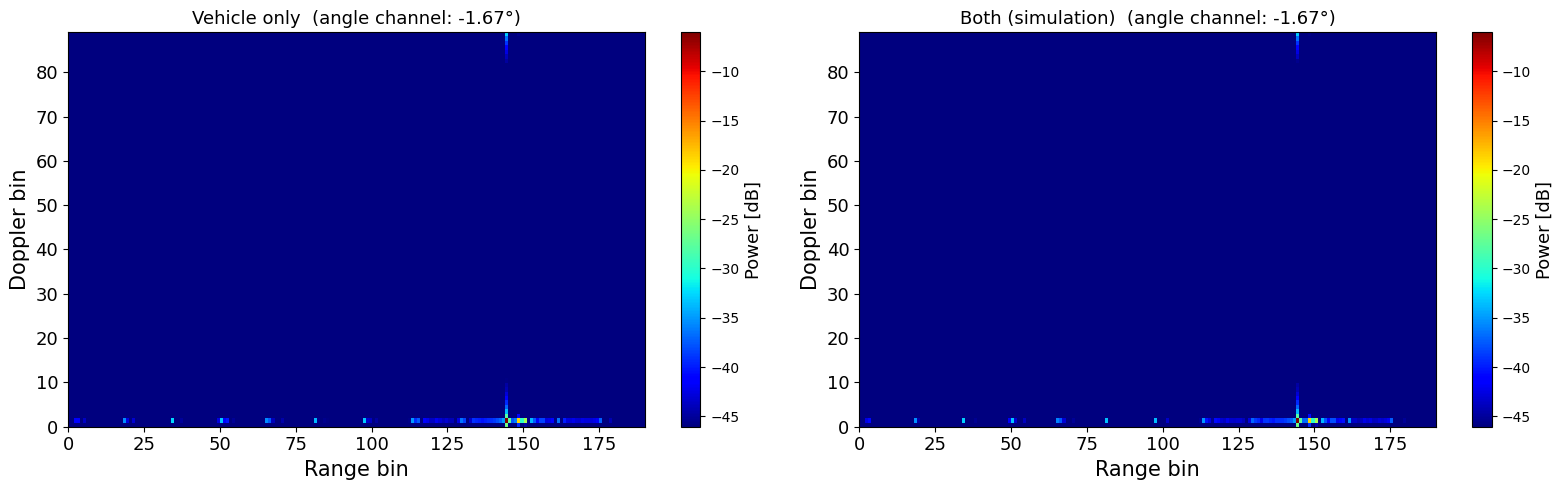

In [87]:

# --- 可視化: vehicle のみ（左） vs both シミュレーション（右） ---
# 両マップを絶対 dB で表示し、共通の vmax で直接比較できるようにする

best_ch = int(np.argmin(np.abs(FIXED_ANGLES - ve_ang)))
ch_label = f'angle channel: {FIXED_ANGLES[best_ch]:.2f}°'

rd_ve_db   = 10 * np.log10(np.abs(rd_maps_ve[best_ch]) ** 2 + 1e-30)
rd_both_db = 10 * np.log10(np.abs(rd_maps[best_ch])    ** 2 + 1e-30)

# 両マップの最大値のうち大きい方を基準に vmax を揃える
vmax_common = max(rd_ve_db.max(), rd_both_db.max())
vmin_common = vmax_common - 40

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title in zip(
    axes,
    [rd_ve_db, rd_both_db],
    [f'Vehicle only  ({ch_label})', f'Both (simulation)  ({ch_label})']
):
    im = ax.imshow(
        data,
        aspect='auto', origin='lower',
        cmap='jet', vmin=vmin_common, vmax=vmax_common,
        extent=[0, data.shape[1], 0, data.shape[0]]
    )
    ax.set_xlabel('Range bin', fontsize=15)
    ax.set_ylabel('Doppler bin', fontsize=15)
    ax.set_title(title, fontsize=13)
    ax.tick_params(labelsize=13)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('Power [dB]', fontsize=13)

plt.tight_layout()
plt.savefig('./rd_map_ve_vs_both.png', dpi=150, bbox_inches='tight')
plt.show()
